In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aishwaryasingh777","key":"1f081a2d77b403b25def0228c37778ec"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d laotse/credit-risk-dataset

Dataset URL: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
License(s): CC0-1.0
100% 368k/368k [00:00<00:00, 137MB/s]



In [4]:
import zipfile

with zipfile.ZipFile("credit-risk-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("credit-risk-dataset")

# Import Libraries

In [5]:
# Load some necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

In [6]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130

# Load the datasets



In [7]:
credit_df = pd.read_csv("/content/credit-risk-dataset/credit_risk_dataset.csv")

# EDA

## BASIC OVERVIEW

In [8]:
print(f"\n{'='*60}")
print(f"DATASET: Credit Risk")
print(f"{'='*60}")

print("\nShape:")
print(credit_df.shape)

print("\nColumns:")
print(credit_df.columns.tolist())

print("\nData Types:")
print(credit_df.dtypes)

print("\nMissing Values:")
print(credit_df.isnull().sum())

print("\nDuplicate Rows:")
print(credit_df.duplicated().sum())

print("\nSample Data:")
display(credit_df.head())

print("\nStatistical summary — numerical features:")
print(credit_df.describe().T.to_string())

print("\nStatistical summary — categorical features:")
print(credit_df.describe(include='object').T.to_string())


DATASET: Credit Risk

Shape:
(32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4



Statistical summary — numerical features:
                              count          mean           std      min       25%       50%       75%         max
person_age                  32581.0     27.734600      6.348078    20.00     23.00     26.00     30.00      144.00
person_income               32581.0  66074.848470  61983.119168  4000.00  38500.00  55000.00  79200.00  6000000.00
person_emp_length           31686.0      4.789686      4.142630     0.00      2.00      4.00      7.00      123.00
loan_amnt                   32581.0   9589.371106   6322.086646   500.00   5000.00   8000.00  12200.00    35000.00
loan_int_rate               29465.0     11.011695      3.240459     5.42      7.90     10.99     13.47       23.22
loan_status                 32581.0      0.218164      0.413006     0.00      0.00      0.00      0.00        1.00
loan_percent_income         32581.0      0.170203      0.106782     0.00      0.09      0.15      0.23        0.83
cb_person_cred_hist_length  32581.0  

| Feature Name | Description |
| --- | --- |
| person_age | Age |
| person_income | Annual Income |
| person_home_ownership | Home ownership |
| person_emp_length | Employment length (in years) |
| loan_intent | Loan intent |
| loan_grade | Loan grade |
| loan_amnt | Loan amount |
| loan_int_rate | Interest rate |
| loan_status | Loan status (0 is non default 1 is default) |
| loan_percent_income | Percent income |
| cb_person_default_on_file | Historical default |
| cb_preson_cred_hist_length | Credit history length |

## MISSING VALUE ANALYSIS

In [9]:
missing       = credit_df.isnull().sum()
missing_pct   = (missing / len(credit_df) * 100).round(2)
missing_df    = pd.DataFrame({'Count': missing, 'Percent %': missing_pct})
missing_df    = missing_df[missing_df['Count'] > 0].sort_values('Percent %', ascending=False)
print(missing_df)

                   Count  Percent %
loan_int_rate       3116       9.56
person_emp_length    895       2.75


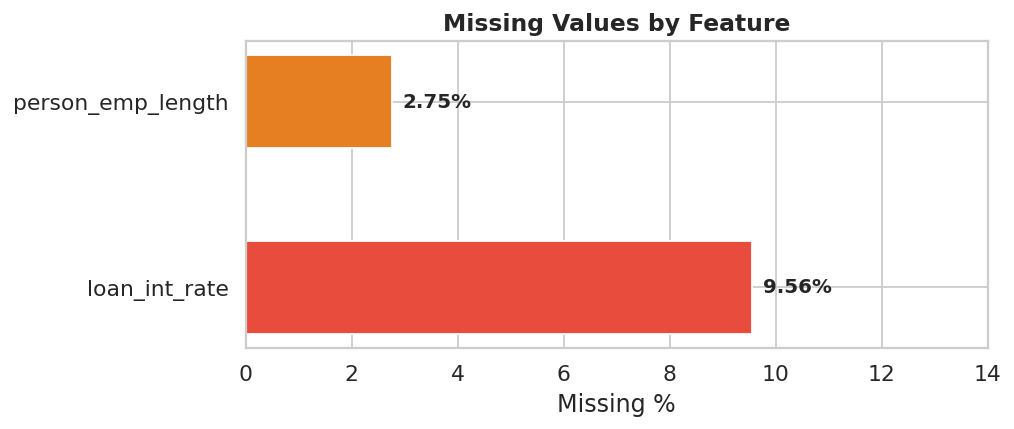

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(missing_df.index, missing_df['Percent %'],
               color=['#e74c3c', '#e67e22'], edgecolor='white', height=0.5)
for bar, val in zip(bars, missing_df['Percent %']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature', fontweight='bold', fontsize=13)
ax.set_xlim(0, 14)
plt.tight_layout()
plt.show()

- `loan_int_rate` — 9.56% missing (3,116 rows)

This is the more serious one. The missingness is likely not random — applicants who were borderline or rejected may not have been assigned a rate yet. Impute with median (not mean) because interest rate is right-skewed.

- `person_emp_length` — 2.75% missing (895 rows)

Smaller gap. Could be self-employed, unemployed, or just unreported. Again, median imputation is the right call.

If you impute before splitting, the test set "sees" information from training data — that's data leakage, which inflates your evaluation metrics artificially.

## TARGET DISTRIBUTION

In [11]:
counts   = credit_df['loan_status'].value_counts()
pct      = credit_df['loan_status'].value_counts(normalize=True) * 100
tgt_df   = pd.DataFrame({'Count': counts, 'Percent %': pct.round(1)})
tgt_df.index = ['No Default (0)', 'Default (1)']
print(tgt_df)

                Count  Percent %
No Default (0)  25473       78.2
Default (1)      7108       21.8


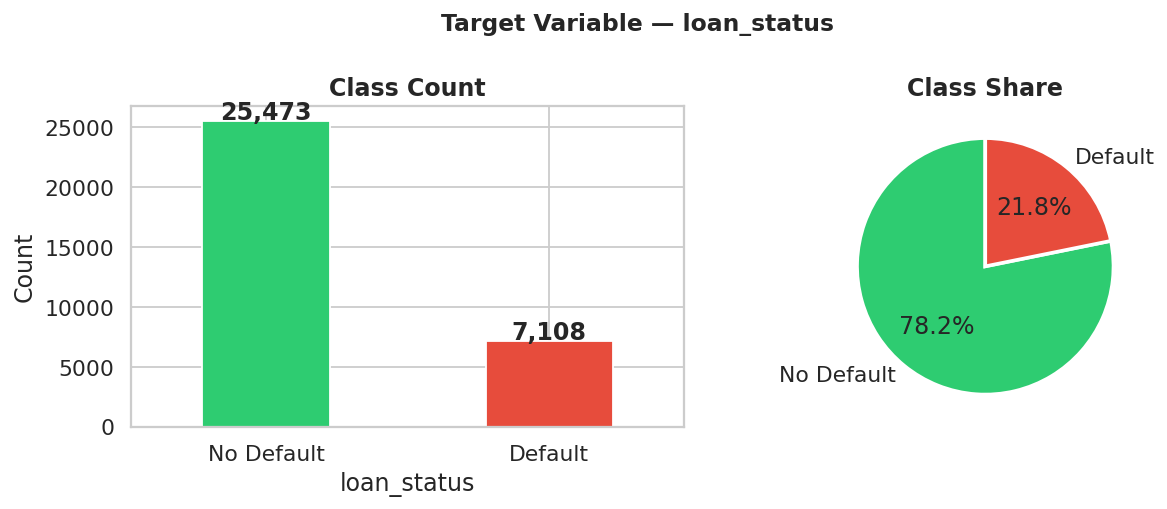

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#2ecc71', '#e74c3c']
labels = ['No Default', 'Default']

counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', width=0.45)
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_title('Class Count', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 200),
                     ha='center', fontweight='bold')

axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Share', fontweight='bold')

plt.suptitle('Target Variable — loan_status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

21.8% default rate — this is called mild-to-moderate class imbalance

If you train logistic regression on this as-is, the model will be biased toward predicting "No Default" because that's the easy way to get 78% accuracy.

We will be using SMOTE to handle this imbalanced data

## NUMERICAL FEATURE DISTRIBUTIONS

### Histogram

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']


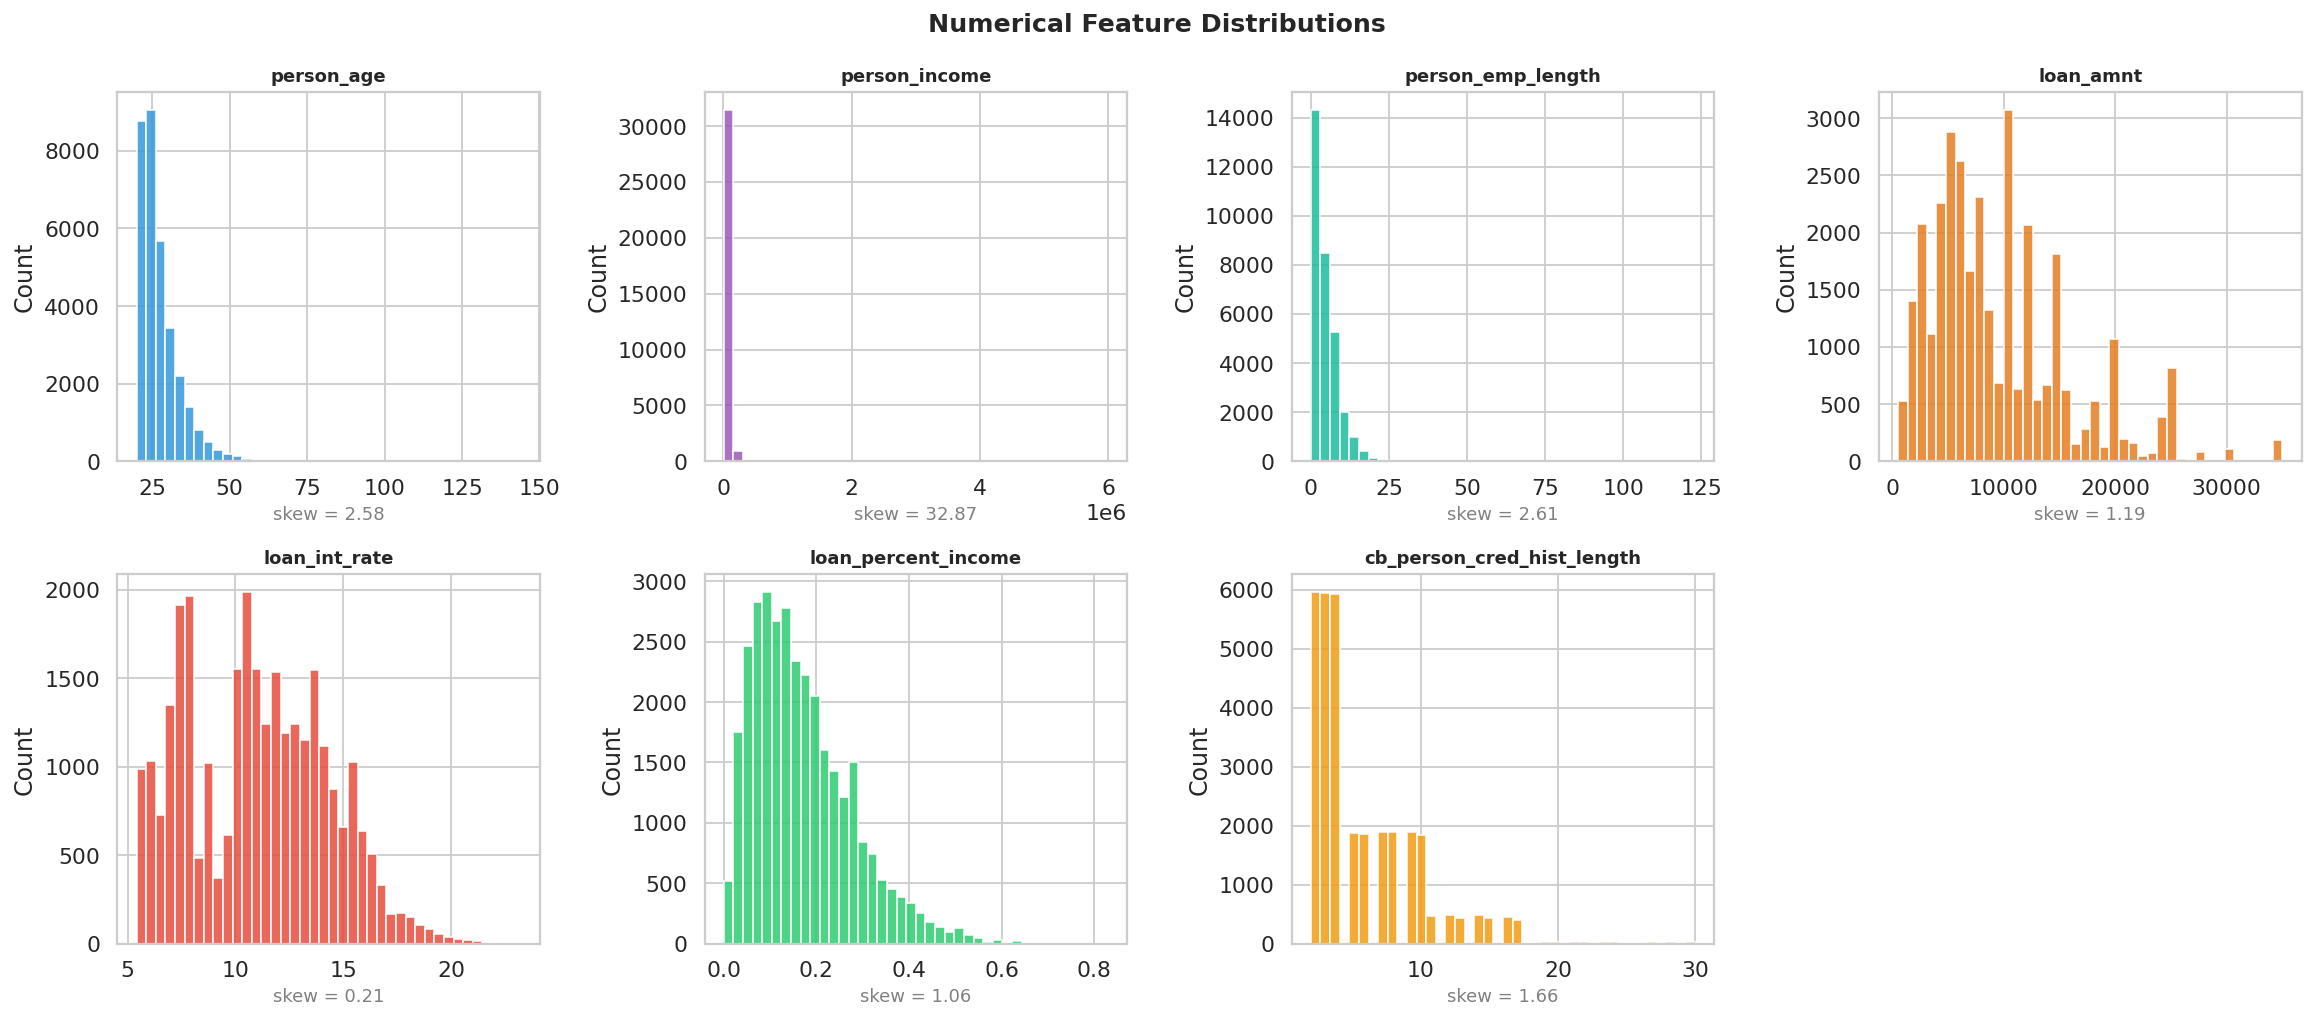

Skewness summary:
  person_age                      : +2.58  !!! log1p-transform recommended
  person_income                   : +32.87  !!! log1p-transform recommended
  person_emp_length               : +2.61  !!! log1p-transform recommended
  loan_amnt                       : +1.19  !!! log1p-transform recommended
  loan_int_rate                   : +0.21  roughly normal
  loan_percent_income             : +1.06  !!! log1p-transform recommended
  cb_person_cred_hist_length      : +1.66  !!! log1p-transform recommended

Why log1p and not log? Because log(0) is undefined. log1p(x) = log(x+1), safely handles zeros


In [13]:
num_cols = credit_df.select_dtypes(include=['number']).columns.tolist()
num_cols.remove('loan_status')
print(num_cols)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
pal  = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22',
        '#e74c3c', '#2ecc71', '#f39c12']

for i, col in enumerate(num_cols):
    axes[i].hist(credit_df[col].dropna(), bins=40, color=pal[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Count')
    skew = credit_df[col].skew()
    axes[i].set_xlabel(f'skew = {skew:.2f}', fontsize=10, color='gray')

axes[-1].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Skewness summary:")
for col in num_cols:
    skew = credit_df[col].skew()
    flag = "!!! log1p-transform recommended" if abs(skew) > 1 else "roughly normal"
    print(f"  {col:<32s}: {skew:+.2f}  {flag}")

print("\nWhy log1p and not log? Because log(0) is undefined. log1p(x) = log(x+1), safely handles zeros")

1. `person_income` — skew 32.87

That purple bar is almost a vertical line — nearly all incomes are crushed near zero with a $6M outlier stretching the axis. This is the most extreme skew in the dataset.

2. `person_age` — skew 2.58

Mostly 20–40 year olds, but that long tail stretching to 144 so we will remove those bad rows.

3. `person_emp_length` — skew 2.61

Same story — that spike near 0 means most people have very short employment history, with a tail to 123 years so we will remove those bad rows.

4. `loan_amnt` — skew 1.19

Reasonably spread but right-skewed. Bimodal-ish shape — smaller personal loans and larger ones as two humps.

5. `loan_percent_income` — skew 1.06

Fairly well-behaved, peaks around 0.1–0.15. Mild right tail. Minor — StandardScaler alone may be sufficient. Minor — StandardScaler alone may be sufficient.

6. `cb_person_cred_hist_length` — skew 1.66

Most people have 2–4 years of credit history.

7. `loan_int_rate` — skew 0.21

The healthiest distribution here — roughly bell-shaped between 5–23%. No transformation needed, StandardScaler is enough.

### Box Plots

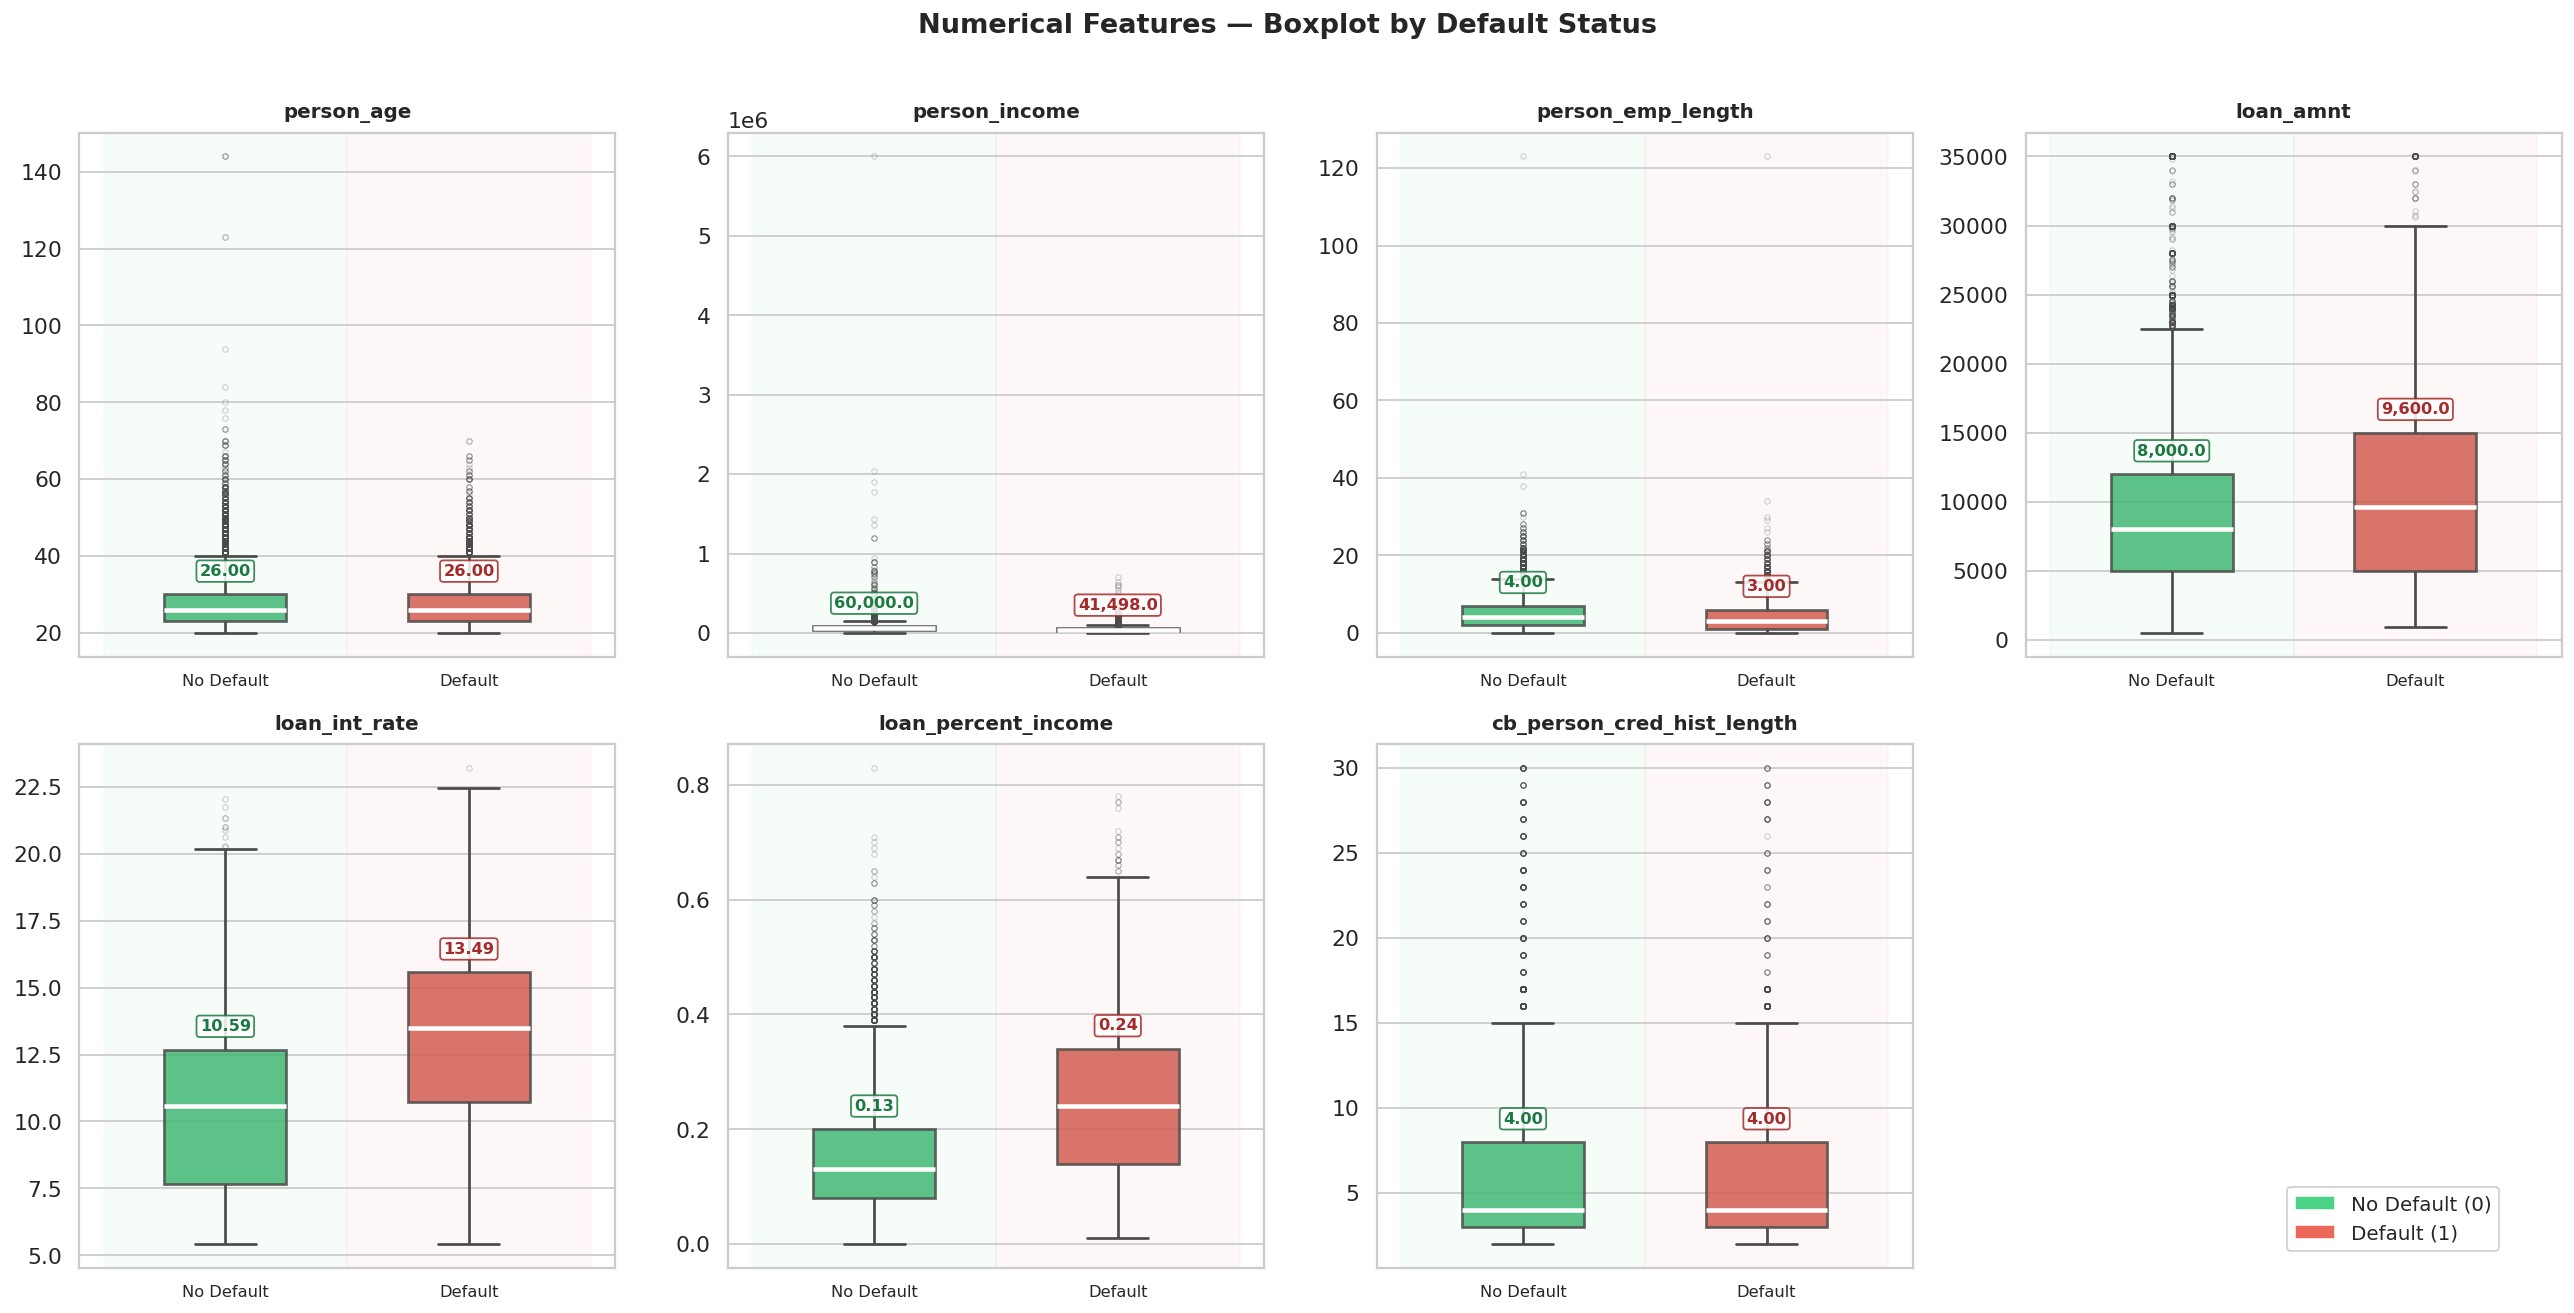

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

palette = {0: '#2ecc71', 1: '#e74c3c'}

for i, col in enumerate(num_cols):
    ax = axes[i]

    sns.boxplot(
        data=credit_df,
        x='loan_status',
        y=col,
        hue='loan_status',
        palette=palette,
        width=0.5,
        linewidth=1.5,
        flierprops=dict(marker='o', markersize=3, alpha=0.3,
                        markeredgewidth=0.5),
        medianprops=dict(color='white', linewidth=2.5),
        boxprops=dict(alpha=0.85),
        ax=ax,
        legend=False
    )

    ax.set_title(col, fontweight='bold', fontsize=11, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Default', 'Default'], fontsize=9)

    ax.axvspan(-0.5, 0.5, alpha=0.04, color='#2ecc71', zorder=0)
    ax.axvspan(0.5, 1.5, alpha=0.04, color='#e74c3c', zorder=0)

    # ── smarter annotation: place ABOVE the box, not on the median line ──
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin

    for cls, xpos, color in zip([0, 1], [0, 1], ['#1a7a40', '#a52a2a']):
        med = credit_df[credit_df['loan_status'] == cls][col].median()
        q3  = credit_df[credit_df['loan_status'] == cls][col].quantile(0.75)

        # format: use scientific for very large values, else 2 decimals
        if abs(med) >= 100000:
            label = f'{med:,.0f}'
        elif abs(med) >= 1000:
            label = f'{med:,.1f}'
        else:
            label = f'{med:.2f}'

        # place label above Q3 with a small offset
        y_pos = q3 + y_range * 0.03

        ax.text(
            xpos, y_pos, label,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color=color,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=color, alpha=0.85, linewidth=1)
        )

axes[-1].set_visible(False)

legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.85, label='No Default (0)'),
    Patch(facecolor='#e74c3c', alpha=0.85, label='Default (1)')
]
fig.legend(handles=legend_elements, loc='lower right',
           bbox_to_anchor=(0.97, 0.05), fontsize=11, framealpha=0.9)

plt.suptitle('Numerical Features — Boxplot by Default Status',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

1. `person_age` — median 26 vs 26 (Weak predictor)

Both classes have identical medians. Age alone doesn't separate defaulters from non-defaulters. The outliers above 100 are the bad data rows to drop.

2. `person_income` — median \$60,000 vs $41,498 (Good predictor)

Clear separation — non-defaulters earn nearly \$ 20k more at the median. Higher income = more repayment capacity. The $6M outlier is visible at the top. Log transform will fix that compression.

3. `person_emp_length` — median 4 vs 3 (Weak)

Only 1 year difference at the median. Boxes heavily overlap. Weak individual predictor but still worth keeping — it adds marginal signal combined with other features.

4. `loan_amnt` — median \$8,000 vs $9,600 (Mild predictor)

Defaulters take slightly larger loans. Not a huge gap but the direction makes sense — bigger loans are harder to repay.

5. `loan_int_rate` — median 10.59% vs 13.49% (Strong predictor)

The most visually obvious separation in the entire chart — a 2.9% median gap with very different box ranges. Red box sits clearly higher than green. This directly confirms loan_int_rate as a top feature. The lender charged more because they sensed the risk.

6. `loan_percent_income` — median 0.13 vs 0.24 (Strongest predictor)

Nearly double the median for defaulters (0.24 vs 0.13). The red box is almost completely above the green box — minimal overlap. This is your single best numerical feature. Someone whose loan is 24% of their annual income is in a very different position than someone at 13%.

7. `cb_person_cred_hist_length` — median 4 vs 4 (Weak)

Identical medians, identical box sizes. Credit history length alone tells you almost nothing about default risk in this dataset.

### Outlier Detection

In [15]:
print("\n Outlier Check (IQR method):")
for col in num_cols:
    Q1, Q3 = credit_df[col].quantile(0.25), credit_df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((credit_df[col] < Q1 - 1.5*IQR) | (credit_df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<35s}: {n_out:4d} outliers ({n_out/len(credit_df)*100:.1f}%)")


 Outlier Check (IQR method):
  person_age                         : 1494 outliers (4.6%)
  person_income                      : 1484 outliers (4.6%)
  person_emp_length                  :  853 outliers (2.6%)
  loan_amnt                          : 1689 outliers (5.2%)
  loan_int_rate                      :    6 outliers (0.0%)
  loan_percent_income                :  651 outliers (2.0%)
  cb_person_cred_hist_length         : 1142 outliers (3.5%)


1. `loan_amnt` — 1,689 outliers (5.2%)

Highest count. Large loans skew the distribution. Cap at 99th percentile then log1p transform.

2. `person_age` — 1,494 outliers (4.6%)

The 5 rows with age > 100 → drop (impossible values)

The remaining ~1,489 are real people aged 50–80 → keep, they're valid

3. `person_income` — 1,484 outliers (4.6%)

The $6M income you saw in the histogram. Real but extreme. Cap at 99th percentile + log1p.

4. `cb_person_cred_hist_length` — 1,142 outliers (3.5%)

People with 15–30 years of credit history are genuinely rare but valid. No action needed — log1p will compress the tail.

5. `person_emp_length` — 853 outliers (2.6%)

The 2 rows with emp_length > 60 → drop (impossible values)
Remaining ~851 with 20–40 years tenure → keep, they're valid senior employees

6. `loan_percent_income` — 651 outliers (2.0%)

High loan-to-income ratios are actually your most important signal for default. Removing them would destroy predictive power.

7. `loan_int_rate` — 6 outliers (0.0%)

Practically zero. Those 6 rates above ~22% are edge cases but valid. No action needed.

## LOAN GRADE vs DEFAULT RATE

In [16]:
credit_df['loan_grade'].value_counts()

,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


In [17]:
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_stats = credit_df.groupby('loan_grade')['loan_status'].agg(['mean', 'count'])
grade_stats.columns = ['Default Rate', 'Count']
grade_stats['Default Rate %'] = (grade_stats['Default Rate'] * 100).round(1)
grade_stats = grade_stats.loc[grade_order]

In [18]:
print(grade_stats[['Count', 'Default Rate %']])

            Count  Default Rate %
loan_grade                       
A           10777            10.0
B           10451            16.3
C            6458            20.7
D            3626            59.0
E             964            64.4
F             241            70.5
G              64            98.4


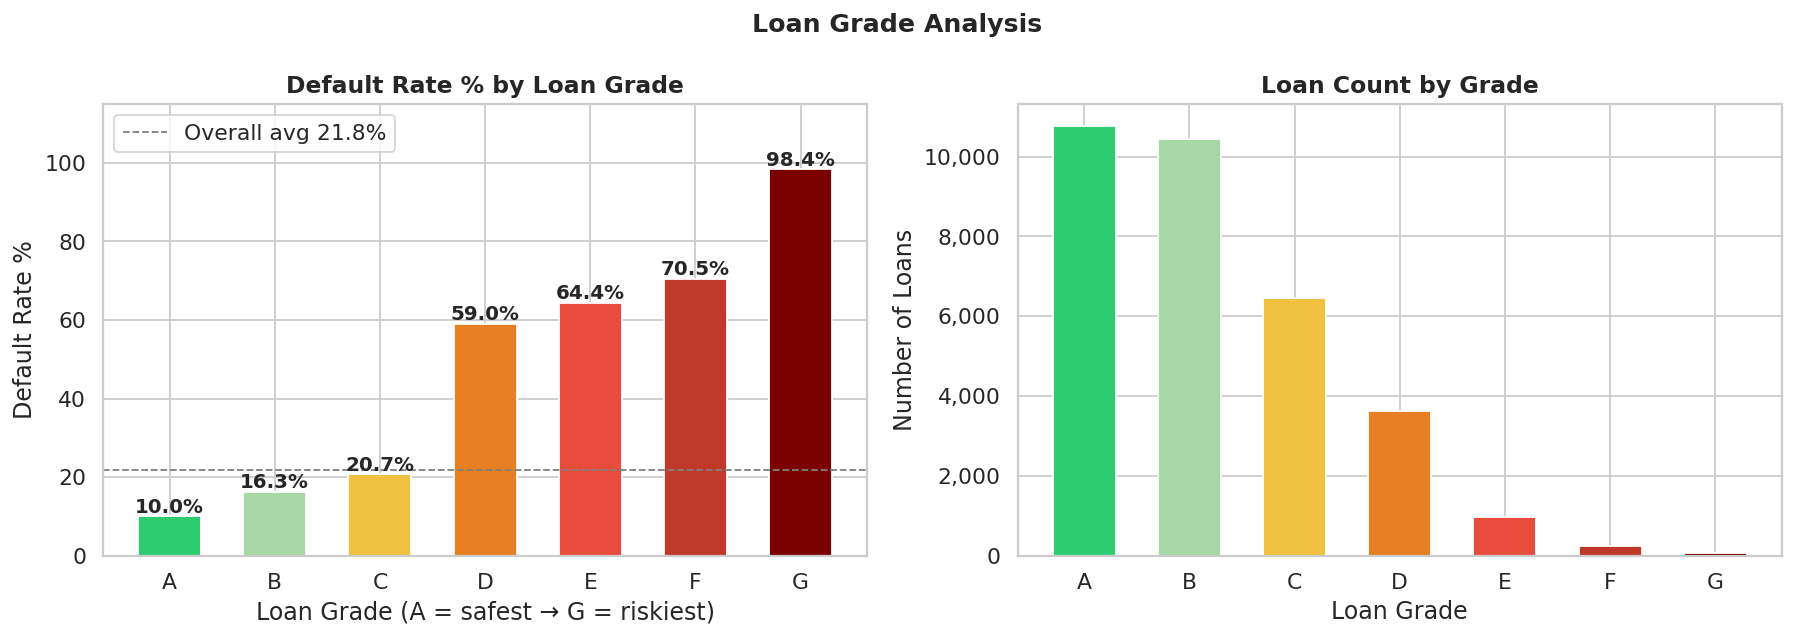

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_grade = ['#2ecc71', '#a8d8a8', '#f0c040', '#e67e22', '#e74c3c', '#c0392b', '#7b0000']

bars = axes[0].bar(grade_stats.index, grade_stats['Default Rate %'],
                   color=colors_grade, edgecolor='white', width=0.6)
for bar, val in zip(bars, grade_stats['Default Rate %']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Default Rate % by Loan Grade', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Loan Grade (A = safest → G = riskiest)')
axes[0].set_ylabel('Default Rate %')
axes[0].set_ylim(0, 115)
axes[0].axhline(21.8, color='gray', linestyle='--', linewidth=1, label='Overall avg 21.8%')
axes[0].legend()

axes[1].bar(grade_stats.index, grade_stats['Count'],
            color=colors_grade, edgecolor='white', width=0.6)
axes[1].set_title('Loan Count by Grade', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('Number of Loans')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Loan Grade Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1. **Default Rate by Loan Grade**

The jump from C to D is the critical threshold — you go from "probably fine" (20.7%) to "probably defaulting" (59%). This is where the lender's risk model draws a hard line.

2. **Loan Count by Grade**

- A and B dominate — ~10,000+ loans each. Most borrowers are low risk.
- E, F, G are tiny — barely visible bars. The bank rarely approves high-risk grades.
- G is almost empty — only a handful of loans. That 98.4% default rate is based on very few observations, so treat it with some caution.